In [3]:
#Importing Libraries and Loading Dataset
import numpy as np
import pandas as pd
df = pd.read_csv('combined_data_1.txt',names = ['Cust_Id', 'Rating'], usecols = [0,1]).copy()

In [4]:
df.head()

,Cust_Id,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0


In [5]:
df['Rating'] = df['Rating'].astype(float)

In [6]:
df.shape

(24058263, 2)

In [7]:
df.dtypes

,0
Cust_Id,object
Rating,float64


In [8]:
ratings_count = df.groupby('Rating')['Rating'].agg(['count'])
ratings_count

,count
Rating,
1.0,1118186
2.0,2439073
3.0,6904181
4.0,8085741
5.0,5506583


In [9]:
movie_count = df.isnull().sum()
movie_count['Rating']

4499

In [10]:
cust_count = df['Cust_Id'].nunique()-movie_count
cust_count['Rating']

470758

In [11]:
rating_count = df['Cust_Id'].count() - movie_count
rating_count['Cust_Id']

24058263

Text(0.5, 1.0, 'Total pool: Cust_Id       0\nRating     4499\ndtype: int64 Movies, Cust_Id    475257\nRating     470758\ndtype: int64 customers, Cust_Id    24058263\nRating     24053764\ndtype: int64 ratings given')

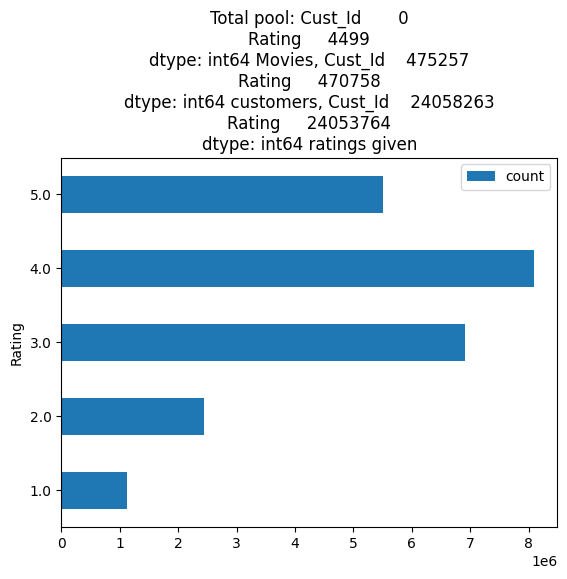

In [12]:
#Data Visualization
import matplotlib.pyplot as plt
ax = ratings_count.plot(kind='barh')
plt.title(f'Total pool: {movie_count} Movies, {cust_count} customers, {rating_count} ratings given')

In [13]:
df_nan = pd.DataFrame(pd.isnull(df.Rating))
df_nan.head()

,Rating
0,True
1,False
2,False
3,False
4,False


In [14]:
df_nan = df_nan[df_nan['Rating'] == True]
df_nan.shape

(4499, 1)

In [15]:
df_nan = df_nan.reset_index()
df_nan.head()

,index,Rating
0,0,True
1,548,True
2,694,True
3,2707,True
4,2850,True


In [16]:
#creating a mapping of Movie IDs for each rating in the dataset
movie_np = []
movie_id = 1

for prev, curr in zip(df_nan['index'][:-1], df_nan['index'][1:]):
    movie_np.append(np.full(curr - prev - 1, movie_id))
    movie_id += 1

last_len = len(df) - df_nan.iloc[-1, 0] - 1
movie_np.append(np.full(last_len, movie_id))
movie_np = np.concatenate(movie_np)

print(f"Movie numpy: {movie_np}")
print(f"Length: {len(movie_np)}")


Movie numpy: [   1    1    1 ... 4499 4499 4499]
Length: 24053764


In [17]:
#Creating Clean Dataset with Movie and Customer IDs
dataset = df[pd.notnull(df['Rating'])].copy()
dataset['Movie_Id'] = movie_np.astype(int)
dataset['Cust_Id'] = dataset['Cust_Id'].astype(int)
print('-Dataset examples-')
print(dataset.head())

-Dataset examples-
   Cust_Id  Rating  Movie_Id
1  1488844     3.0         1
2   822109     5.0         1
3   885013     4.0         1
4    30878     4.0         1
5   823519     3.0         1


In [18]:
#Filtering Movies Based on Rating Count Threshold
f = ['count','mean']
dataset_movie_summary = dataset.groupby('Movie_Id')['Rating'].agg(f)
dataset_movie_summary.index = dataset_movie_summary.index.map(int)
movie_benchmark = round(dataset_movie_summary['count'].quantile(0.7),0)
drop_movie_list = dataset_movie_summary[dataset_movie_summary['count'] < movie_benchmark].index
print('Movie minimum times of review: {}'.format(movie_benchmark))

Movie minimum times of review: 1799.0


In [19]:
#Filtering Customers Based on Rating Count Threshold
dataset_cust_summary = dataset.groupby('Cust_Id')['Rating'].agg(f) #mean and count of customer id
dataset_cust_summary.index = dataset_cust_summary.index.map(int) #integer format
cust_benchmark = round(dataset_cust_summary['count'].quantile(0.7),0)
drop_cust_list = dataset_cust_summary[dataset_cust_summary['count'] < cust_benchmark].index

print(f'Customer minimum times of review: {cust_benchmark}')

Customer minimum times of review: 52.0


In [20]:
#Trimming Dataset by Removing Inactive Customers and Unpopular Movies
dataset = dataset[~dataset['Movie_Id'].isin(drop_movie_list)]
dataset = dataset[~dataset['Cust_Id'].isin(drop_cust_list)]
print('After Trim Shape: {}'.format(dataset.shape))

After Trim Shape: (17337458, 3)


In [21]:
df_p = pd.pivot_table(dataset,values='Rating',index='Cust_Id',columns='Movie_Id')
print(df_p.shape)

(143458, 1350)


In [22]:
import pandas as pd
df_title = pd.read_csv(
    "movie_titles.csv",
    encoding="ISO-8859-1",
    header=None,
    names=["Movie_Id", "Year", "Name"],
    on_bad_lines="skip"
)

df_title = df_title.set_index("Movie_Id")
print(df_title.head(10))



            Year                          Name
Movie_Id                                      
1         2003.0               Dinosaur Planet
2         2004.0    Isle of Man TT 2004 Review
3         1997.0                     Character
4         1994.0  Paula Abdul's Get Up & Dance
5         2004.0      The Rise and Fall of ECW
6         1997.0                          Sick
7         1992.0                         8 Man
8         2004.0    What the #$*! Do We Know!?
9         1991.0      Class of Nuke 'Em High 2
10        2001.0                       Fighter


In [23]:
!pip install scikit-surprise

In [24]:
!pip uninstall numpy

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Would remove:
    /usr/local/bin/f2py
    /usr/local/lib/python3.12/dist-packages/numpy-1.26.4.dist-info/*
    /usr/local/lib/python3.12/dist-packages/numpy.libs/libgfortran-040039e1.so.5.0.0
    /usr/local/lib/python3.12/dist-packages/numpy.libs/libopenblas64_p-r0-0cf96a72.3.23.dev.so
    /usr/local/lib/python3.12/dist-packages/numpy.libs/libquadmath-96973f99.so.0.0.0
    /usr/local/lib/python3.12/dist-packages/numpy/*
Proceed (Y/n)? y
  Successfully uninstalled numpy-1.26.4


In [25]:
!pip install "numpy<2"

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


In [26]:
import math
import matplotlib.pyplot as plt
from surprise import Reader, Dataset, SVD
from surprise.model_selection import cross_validate

In [27]:
#Building and Evaluating SVD Model with Cross-Validation
reader = Reader()
data = Dataset.load_from_df(dataset[['Cust_Id', 'Movie_Id', 'Rating']][:100000], reader)
svd = SVD()
cross_validate(svd, data, measures=['RMSE', 'MAE'], cv=3, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 3 split(s).

                  Fold 1  Fold 2  Fold 3  Mean    Std     
RMSE (testset)    0.9965  0.9943  0.9999  0.9969  0.0023  
MAE (testset)     0.8058  0.7989  0.7987  0.8011  0.0033  
Fit time          2.15    2.70    2.59    2.48    0.24    
Test time         0.29    0.43    0.33    0.35    0.06    


{'test_rmse': array([0.99647905, 0.99428223, 0.99993957]),
 'test_mae': array([0.80578086, 0.79886292, 0.79868112]),
 'fit_time': (2.1535675525665283, 2.7039847373962402, 2.591360569000244),
 'test_time': (0.2853677272796631, 0.4322695732116699, 0.3306713104248047)}

In [28]:
#Retrieving Favorite Movies (5-Star Ratings) of user 30878
dataset_30878 = dataset[(dataset['Cust_Id'] == 30878) & (dataset['Rating'] == 5)]
dataset_30878 = dataset_30878.set_index('Movie_Id')
dataset_30878 = dataset_30878.join(df_title)['Name']
dataset_30878.head(10)

,Name
Movie_Id,
44,Spitfire Grill
232,Gross Anatomy
329,Dogma
442,Mississippi Burning
443,Rabbit-Proof Fence
528,The Hitchhiker's Guide to the Galaxy
629,Firestarter
1144,Fried Green Tomatoes
1561,American Wedding


In [29]:
#Generating Top Movie Recommendations for 30878 user
user_30878 = df_title.copy()
user_30878 = user_30878.reset_index()
user_30878 = user_30878[~user_30878['Movie_Id'].isin(drop_movie_list)]
data = Dataset.load_from_df(dataset[['Cust_Id', 'Movie_Id', 'Rating']], reader)
trainset = data.build_full_trainset()
svd.fit(trainset)
user_30878['Estimate_Score'] = user_30878['Movie_Id'].apply(lambda x: svd.predict(30878, x).est)
user_30878 = user_30878.drop('Movie_Id', axis = 1)
user_30878 = user_30878.sort_values('Estimate_Score', ascending=False)

In [31]:
print(f'Top Recomended movies for User 30878 \n {user_30878}')

Top Recomended movies for User 30878 
         Year                                Name  Estimate_Score
2078  2002.0                             Firefly        4.994094
4344  2001.0             The West Wing: Season 3        4.751607
2022  2001.0  Buffy the Vampire Slayer: Season 6        4.724001
3391  2004.0                      Lost: Season 1        4.705746
2859  2004.0                   Finding Neverland        4.669120
...      ...                                 ...             ...
737   1990.0                 Ernest Goes to Jail        2.104963
2966  2003.0                   House of the Dead        2.072009
650   1972.0          The Last House on the Left        2.037068
4175  2002.0                               Gerry        1.971229
3440  2001.0                 Freddy Got Fingered        1.959349

[14353 rows x 3 columns]
